## XGBoost For Congestion (Classification)

### Replication of preprocessing from logistic regression baseline:
    - Load data and sample
    - Drop unnecessary columns and encode remaining categorical features
    - Split into train/test sets

In [23]:
# import libraries

# data handling
import pandas as pd
import numpy as np

# model
from xgboost import XGBClassifier, XGBRegressor

# train/test split (if not already done)
from sklearn.model_selection import train_test_split

# scaling data
from sklearn.preprocessing import StandardScaler

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    auc,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# optional: ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


#### Load Data and Sample

In [24]:
# load engineered data
data = pd.read_parquet("../../data/processed/taxi_engineered.parquet")
data.head()
#data.columns

,VendorID,tpep_pickup_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,is_extreme_fare,store_and_fwd_encoded,payment_name,ratecode_name,hour_x_dayofweek,time_slot,cbd_fee_ratio,total_surcharges,surcharges_ratio,base_fare_ratio
0,2,2025-01-05 00:00:02,1.0,8.66,1.0,138,43,1,35.200001,6.0,...,0,0,credit,standard,0,144,0.0,16.190001,25.202366,54.794521
1,2,2025-01-05 00:24:51,1.0,9.73,1.0,138,61,1,40.799999,6.0,...,0,0,credit,standard,0,144,0.0,9.250000,15.401265,67.932068
2,2,2025-01-05 00:54:12,1.0,10.33,1.0,138,62,1,41.500000,6.0,...,0,0,credit,standard,0,144,0.0,9.250000,15.226337,68.312759
3,2,2025-01-05 00:10:19,1.0,1.71,1.0,239,24,1,9.300000,1.0,...,0,0,credit,standard,0,144,0.0,5.000000,29.137529,54.195805
4,2,2025-01-05 00:29:32,1.0,1.80,1.0,236,143,1,10.700000,1.0,...,0,0,credit,standard,0,144,0.0,5.000000,26.539278,56.794056


In [25]:
# take 100,000 rows (adjust if needed)
data = data.sample(n=100_000, random_state=42)

print("Sampled dataset shape:", data.shape)

Sampled dataset shape: (100000, 45)


#### Drop unnecessary columns and encode remaining categorical features

In [26]:
# drop unnecessary columns 
drop_cols = [
    # TARGETS
    "trip_duration_min",
    "has_congestion_fee",
    
    # RAW TIMESTAMP (time features already extracted)
    "tpep_pickup_datetime",
    
    # POST-TRIP FINANCIAL DATA
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    
    # LEAKY DERIVED FEATURES
    "avg_speed_mph",           # uses trip_duration_min in calculation
    "tip_to_total_ratio",      # post-trip
    "is_extreme_fare",         # based on fare_amount
    "cbd_fee_ratio",           # based on cbd_congestion_fee
    "total_surcharges",        # sum of post-trip surcharges
    "surcharges_ratio",        # post-trip ratio
    "base_fare_ratio",         # post-trip ratio
    
    # NOT PREDICTIVE FOR DURATION
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name"
]

existing_drop = [c for c in drop_cols if c in data.columns]
X_congestion = data.drop(columns=existing_drop)
y_congestion = data["has_congestion_fee"]

print("Feature matrix shape:", X_congestion.shape)

Feature matrix shape: (100000, 21)


In [27]:
# encode categorical features
from sklearn.preprocessing import LabelEncoder

cat_cols = X_congestion.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Convert category dtype to string FIRST, then fill NaN
    if X_congestion[col].dtype.name == 'category':
        X_congestion[col] = X_congestion[col].astype(str)
    X_congestion[col] = X_congestion[col].fillna("Unknown")
    X_congestion[col] = le.fit_transform(X_congestion[col])
    label_encoders[col] = le
    print(f"  ✅ {col}: {len(le.classes_)} unique values → encoded")

Categorical columns: ['time_of_day', 'pickup_borough', 'dropoff_borough', 'distance_category', 'ratecode_name']

  ✅ time_of_day: 4 unique values → encoded
  ✅ pickup_borough: 6 unique values → encoded
  ✅ dropoff_borough: 7 unique values → encoded
  ✅ distance_category: 3 unique values → encoded
  ✅ ratecode_name: 5 unique values → encoded


#### Split into train/test sets

In [28]:
# split into train and test sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_congestion, y_congestion,
    test_size=0.2,
    random_state=42,
    stratify=y_congestion
)

#### Build XGBoost Classifier

In [29]:
congestion_xgb = XGBClassifier(
    n_estimators=100,           # number of trees (more = more powerful but slower)
    learning_rate=0.1,          # step size (lower = slower but more accurate)
    max_depth=6,                # depth of each tree (controls complexity)
    random_state=42,            # ensures reproducibility
)

In [30]:
# train the model
congestion_xgb.fit(X_train_c, y_train_c)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [31]:
# make predictions (0 = no congestion fee, 1 = congestion fee)
y_pred_c = congestion_xgb.predict(X_test_c)

# predicted probabilities for ROC AUC
y_prob_c = congestion_xgb.predict_proba(X_test_c)[:, 1]

In [32]:
# print evaluation metrics
print("\n=== Classification Results ===")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("ROC AUC:", roc_auc_score(y_test_c, y_prob_c))
print("XGBoost Classification Report:\n")
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))


=== Classification Results ===
Accuracy: 0.96225
ROC AUC: 0.9850854401374175
XGBoost Classification Report:


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      5118
           1       0.98      0.97      0.97     14882

    accuracy                           0.96     20000
   macro avg       0.94      0.96      0.95     20000
weighted avg       0.96      0.96      0.96     20000



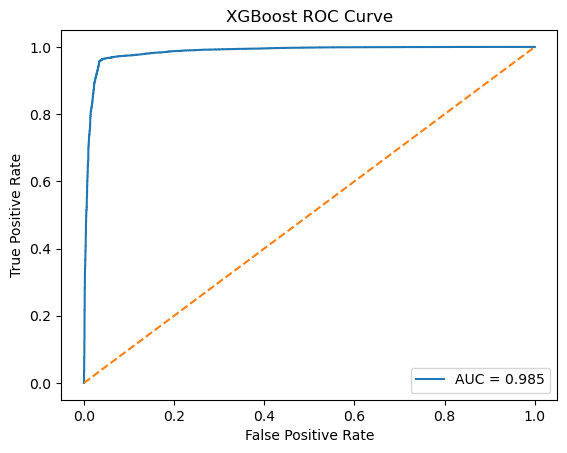

In [33]:
# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

# Diagonal line = random guessing
plt.plot([0, 1], [0, 1], linestyle='--')

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()

# Show plot
plt.show()

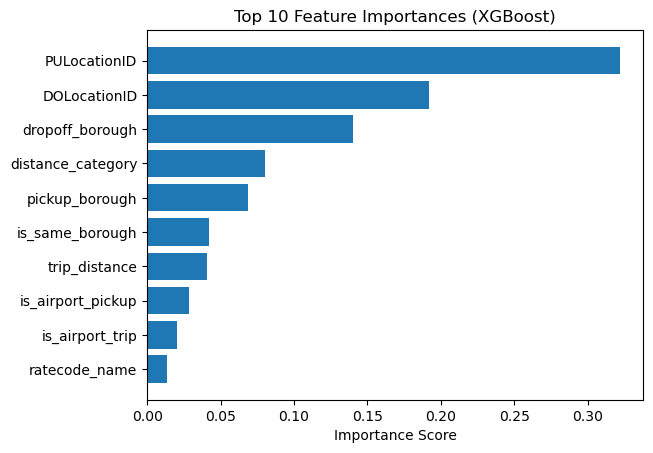

In [34]:
import pandas as pd

# Create a DataFrame for sorting
feat_imp = pd.DataFrame({
    "Feature": X_congestion.columns,
    "Importance": congestion_xgb.feature_importances_
})

# Sort descending
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

# Plot top 10
plt.figure()
plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])

plt.gca().invert_yaxis()  # highest importance at top

plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")

plt.show()

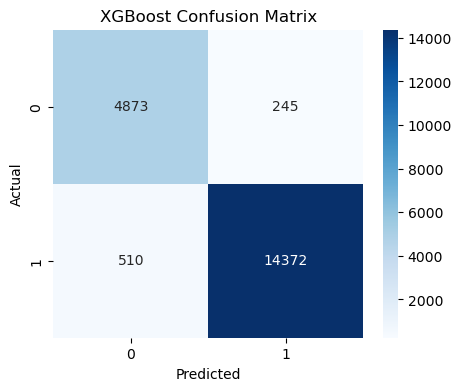

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

## XGBoost For Trip Duration (Regression)

### Drop Unnecessary Columns and Encode

In [36]:
# drop unnecessary columns 
drop_cols_reg = [
    # TARGETS
    "trip_duration_min",
    "has_congestion_fee",
    
    # RAW TIMESTAMP (time features already extracted)
    "tpep_pickup_datetime",
    
    # POST-TRIP FINANCIAL DATA
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    
    # LEAKY DERIVED FEATURES
    "avg_speed_mph",           # uses trip_duration_min in calculation
    "tip_to_total_ratio",      # post-trip
    "is_extreme_fare",         # based on fare_amount
    "cbd_fee_ratio",           # based on cbd_congestion_fee
    "total_surcharges",        # sum of post-trip surcharges
    "surcharges_ratio",        # post-trip ratio
    "base_fare_ratio",         # post-trip ratio
    
    # NOT PREDICTIVE FOR DURATION
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name"
]

existing_drop = [c for c in drop_cols_reg if c in data.columns]
X_duration = data.drop(columns=existing_drop)
y_duration = data["trip_duration_min"]

print("Feature matrix shape:", X_duration.shape)

Feature matrix shape: (100000, 21)


In [37]:
# encode categorical features
from sklearn.preprocessing import LabelEncoder

cat_cols = X_duration.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Convert category dtype to string FIRST, then fill NaN
    if X_duration[col].dtype.name == 'category':
        X_duration[col] = X_duration[col].astype(str)
    X_duration[col] = X_duration[col].fillna("Unknown")
    X_duration[col] = le.fit_transform(X_duration[col])
    label_encoders[col] = le
    print(f"  ✅ {col}: {len(le.classes_)} unique values → encoded")

Categorical columns: ['time_of_day', 'pickup_borough', 'dropoff_borough', 'distance_category', 'ratecode_name']

  ✅ time_of_day: 4 unique values → encoded
  ✅ pickup_borough: 6 unique values → encoded
  ✅ dropoff_borough: 7 unique values → encoded
  ✅ distance_category: 3 unique values → encoded
  ✅ ratecode_name: 5 unique values → encoded


In [38]:
# split into train and test sets
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_duration, y_duration,
    test_size=0.2,
    random_state=42
)

In [39]:
duration_xgb = XGBRegressor(
    n_estimators=100,           # number of trees (more = more powerful but slower)
    learning_rate=0.1,          # step size (lower = slower but more accurate)
    max_depth=6,                # depth of each tree (controls complexity)
    random_state=42,            # ensures reproducibility
)

duration_xgb.fit(X_train_d, y_train_d)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [40]:
y_pred_d = duration_xgb.predict(X_test_d)

# print evaluation metrics
print("\n=== Regression Results ===")
print("MAE:", mean_absolute_error(y_test_d, y_pred_d))
print("RMSE:", np.sqrt(mean_squared_error(y_test_d, y_pred_d)))
print("R²:", r2_score(y_test_d, y_pred_d))


=== Regression Results ===
MAE: 2.699845314025879
RMSE: 4.13353424404343
R²: 0.8485966324806213


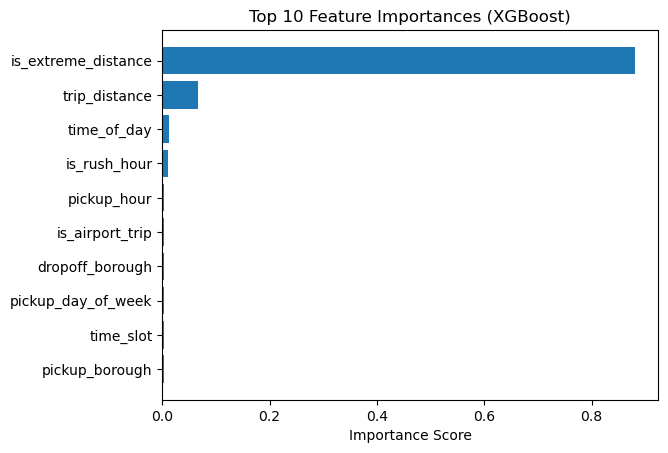

In [41]:
# Create a DataFrame for sorting
feat_imp = pd.DataFrame({
    "Feature": X_duration.columns,
    "Importance": duration_xgb.feature_importances_
})

# Sort descending
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

# Plot top 10
plt.figure()
plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])

plt.gca().invert_yaxis()  # highest importance at top

plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")

plt.show()